# Plot Cached Runs By Error Rank

This notebook inspects per-run objects stored in `raw_runs_ref` (schema v3).

Features:
- Rank all cached runs by each run object's `mean_error`.
- Plot any one or multiple ranked runs with automatic subplot layout.
- Use the same plotting logic as `eval_grid_results.py` / `ModelEval.plot_accuracy_comparison`:
  Predicted = `sliding_pred_acc`, True = `sliding_true_acc`, shaded band = `sliding_pred_acc_std`.

Notes:
- This notebook intentionally has **no fallback** to legacy `raw_step_results_ref`.
- If required fields are missing, it raises errors immediately for easier debugging.

In [9]:
from __future__ import annotations

import json
import math
from pathlib import Path
from typing import Iterable, Sequence

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def find_project_root(start: Path | None = None) -> Path:
    p = (start or Path.cwd()).resolve()
    for cand in [p, *p.parents]:
        if (cand / "pyproject.toml").exists() and (cand / "src").exists():
            return cand
    raise RuntimeError("Could not locate project root from current working directory.")


ROOT = find_project_root()
NOTEBOOK_DIR = ROOT / "notebooks"
RESULTS_DIR = ROOT / "results" / "state-based-grid-result" / "pmh" / "cond3"
DATA_PATH = ROOT / "data" / "processed" / "Task2_processed_new.csv"

import sys
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.Bayesian_state.utils.stream import StreamList

ROOT, RESULTS_DIR

(PosixPath('/home/zhuran/ran/CategoryLearning'),
 PosixPath('/home/zhuran/ran/CategoryLearning/results/state-based-grid-result/pmh/cond3'))

In [10]:
def load_subject_payload(subject_json_path: str | Path) -> dict:
    path = Path(subject_json_path)
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def _load_run_stream(payload: dict, subject_json_path: str | Path) -> StreamList:
    subject_json_path = Path(subject_json_path)
    ref = payload.get("raw_runs_ref") or {}
    rel = ref.get("path")
    cnt = int(ref.get("count", 0))

    if not rel or cnt <= 0:
        raise ValueError(
            "raw_runs_ref is missing or invalid. "
            "This notebook requires schema v3 results with per-run objects."
        )

    abs_stream = (subject_json_path.parent / rel).resolve()
    if not abs_stream.exists():
        raise FileNotFoundError(f"Run stream file not found: {abs_stream}")

    return StreamList(str(abs_stream), cnt)


def rank_runs_by_error(payload: dict, subject_json_path: str | Path) -> pd.DataFrame:
    stream = _load_run_stream(payload, subject_json_path)

    rows = []
    for idx, run_obj in enumerate(stream):
        if not isinstance(run_obj, dict):
            raise TypeError(f"Run object at stream index {idx} is not a dict")

        run_index = run_obj.get("run_index", None)
        if run_index is None:
            raise KeyError(f"run_index missing at stream index {idx}")
        run_index = int(run_index)

        if run_index != idx:
            raise ValueError(
                f"run_index mismatch: object has {run_index} but stream index is {idx}"
            )

        err = run_obj.get("mean_error", None)
        if err is None:
            raise KeyError(f"mean_error missing for run_index={run_index}")

        rows.append({"run_index": run_index, "error": float(err)})

    if len(rows) == 0:
        raise ValueError("No run objects found in raw_runs_ref stream")

    df = pd.DataFrame(rows).sort_values("error", ascending=True).reset_index(drop=True)
    df["rank"] = np.arange(1, len(df) + 1)
    return df[["rank", "run_index", "error"]]



In [11]:
def _as_float_1d(values, field_name: str) -> np.ndarray:
    arr = np.asarray(values, dtype=float).reshape(-1)
    if arr.size == 0:
        raise ValueError(f"{field_name} is empty")
    return arr


def _extract_eval_curves(run_obj: dict) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    metrics = run_obj.get("metrics", None)
    if not isinstance(metrics, dict):
        raise KeyError("Run object is missing metrics dict")

    true_acc = _as_float_1d(metrics.get("sliding_true_acc", None), "sliding_true_acc")
    pred_acc = _as_float_1d(metrics.get("sliding_pred_acc", None), "sliding_pred_acc")
    pred_std = _as_float_1d(metrics.get("sliding_pred_acc_std", None), "sliding_pred_acc_std")

    if not (len(true_acc) == len(pred_acc) == len(pred_std)):
        raise ValueError(
            "Metric length mismatch in run object: "
            f"true={len(true_acc)}, pred={len(pred_acc)}, std={len(pred_std)}"
        )

    return true_acc, pred_acc, pred_std


def plot_runs_by_rank(
    subject_json_path: str | Path,
    ranks: int | Sequence[int],
    *,
    n_cols: int = 3,
) -> pd.DataFrame:
    subject_json_path = Path(subject_json_path)
    payload = load_subject_payload(subject_json_path)
    rank_df = rank_runs_by_error(payload, subject_json_path)
    stream = _load_run_stream(payload, subject_json_path)

    if isinstance(ranks, int):
        ranks = [ranks]
    ranks = [int(r) for r in ranks]
    if len(ranks) == 0:
        raise ValueError("Please provide at least one rank")

    selected = rank_df[rank_df["rank"].isin(ranks)].copy()
    if selected.empty:
        raise ValueError("None of the requested ranks exist")
    selected = selected.sort_values("rank").reset_index(drop=True)

    n = len(selected)
    n_cols = max(1, int(n_cols))
    n_rows = math.ceil(n / n_cols)

    sid = int(payload.get("subject_id", -1))
    cond = int(payload.get("condition", -1))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows), squeeze=False)
    axes_flat = axes.ravel()

    for i, row in selected.iterrows():
        ax = axes_flat[i]

        run_idx = int(row["run_index"])
        err = float(row["error"])
        run_obj = stream[run_idx]

        if int(run_obj.get("run_index", -999)) != run_idx:
            raise ValueError(
                f"Loaded run object mismatch: expected run_index={run_idx}, "
                f"got {run_obj.get('run_index')}"
            )

        true_acc, pred_acc, pred_std = _extract_eval_curves(run_obj)
        x = np.arange(len(pred_acc))

        ax.plot(x, pred_acc, label="Predicted", lw=2)
        ax.plot(x, true_acc, label="True", lw=2)
        ax.fill_between(x, pred_acc - pred_std, pred_acc + pred_std, alpha=0.2)

        ax.set_ylim(0.0, 1.0)
        ax.set_xlabel("Trial")
        ax.set_ylabel("Accuracy")
        ax.set_title(
            f"Sub {sid} | Cond {cond} | Rank {int(row['rank'])} | "
            f"Run #{run_idx} | Error={err:.6f}"
        )
        ax.grid(alpha=0.25)
        ax.legend(loc="best")

    for j in range(n, len(axes_flat)):
        axes_flat[j].axis("off")

    fig.suptitle(
        f"Predicted vs True Accuracy by Run (Subject {sid}, Condition {cond})",
        fontsize=14,
        y=1.02,
    )
    plt.tight_layout()
    plt.show()

    return selected

,rank,run_index,error
0,1,2874,0.074225
1,2,3759,0.074810
2,3,2288,0.075996
3,4,2038,0.076498
4,5,2360,0.076689
5,6,880,0.077103
6,7,2714,0.079168
7,8,3481,0.079324
8,9,3697,0.079521
9,10,2031,0.079788


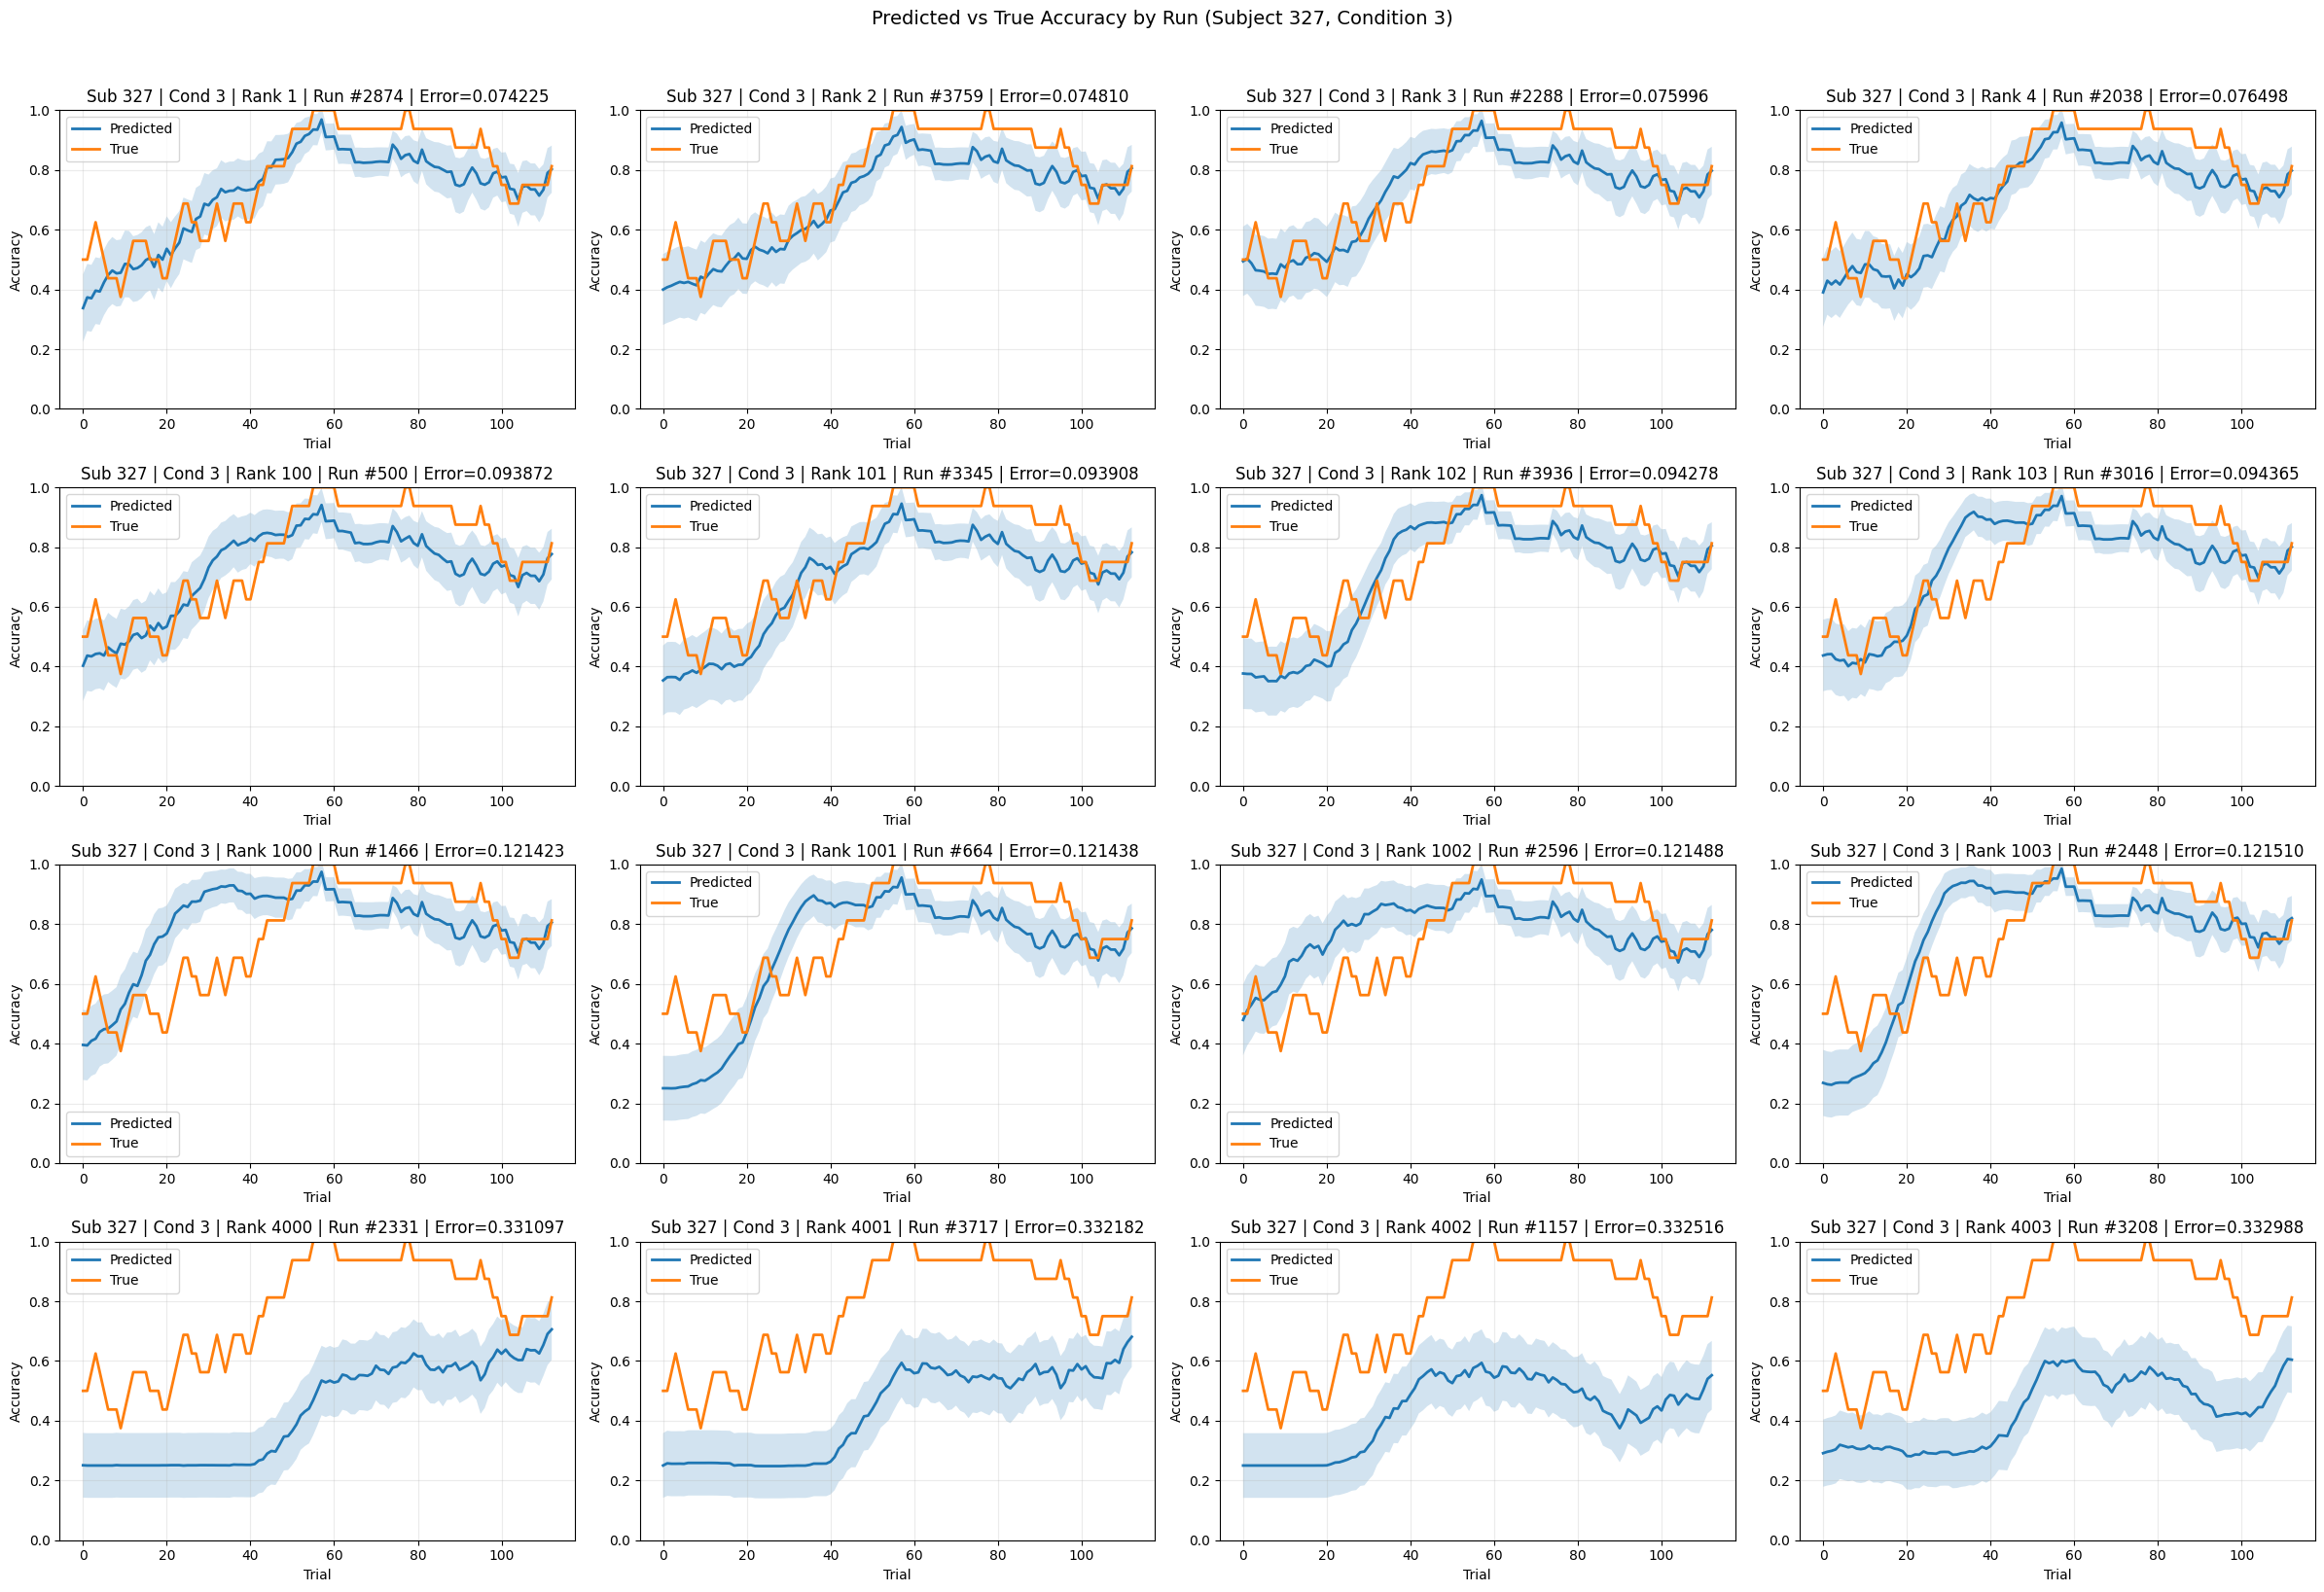

,rank,run_index,error
0,1,2874,0.074225
1,2,3759,0.074810
2,3,2288,0.075996
3,4,2038,0.076498
4,100,500,0.093872
5,101,3345,0.093908
6,102,3936,0.094278
7,103,3016,0.094365
8,1000,1466,0.121423
9,1001,664,0.121438


In [14]:
# Example usage:
# 1) Change subject file
subject_json = RESULTS_DIR / "subject_327.json"

# 2) Inspect top ranked runs by error
payload = load_subject_payload(subject_json)
rank_df = rank_runs_by_error(payload, subject_json)
display(rank_df.head(20))

# 3) Plot arbitrary rank IDs (single or multiple)
selected_info = plot_runs_by_rank(
    subject_json_path=subject_json,
    ranks=[1, 2, 3, 4, 100, 101, 102, 103, 1000, 1001, 1002, 1003, 4000, 4001, 4002, 4003,],
    n_cols=4,
)
display(selected_info)